In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv('datafinal.csv', skiprows=1)


In [4]:
X = data.select_dtypes(include=[np.number]).iloc[:, :-1]
y = data.iloc[:, -1]

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.3, random_state=42)

In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

In [8]:
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor()
model.fit(X_train, y_train)

DecisionTreeRegressor()

In [9]:
y_pred = regressor.predict(X_test)

In [10]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

In [11]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [12]:
from sklearn.metrics import  r2_score
r2 = r2_score(y_test, y_pred)

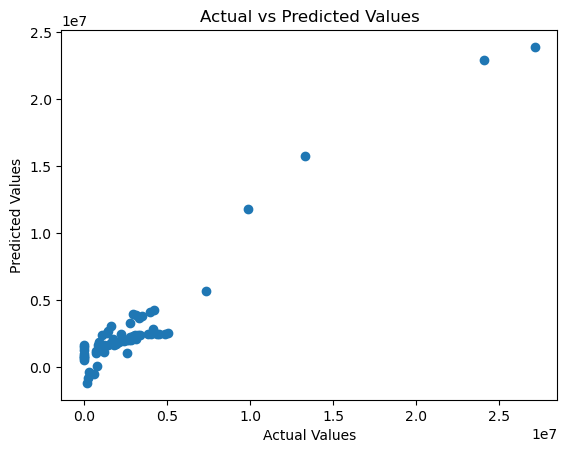

Mean Squared Error: 1402030533827.5388
R-squared: 0.938410483322272
decision tree: 0.9932841598655081
RMSE: 1184073.70286969
Random Forest R-squared: 0.9982969035371337


In [14]:
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.show()
print ("Mean Squared Error:", mse)
print ("R-squared:", r2)
print("decision tree:", model.score(X_test, y_test))
print("RMSE:", rmse)
print("Random Forest R-squared:", rf_model.score(X_test, y_test))


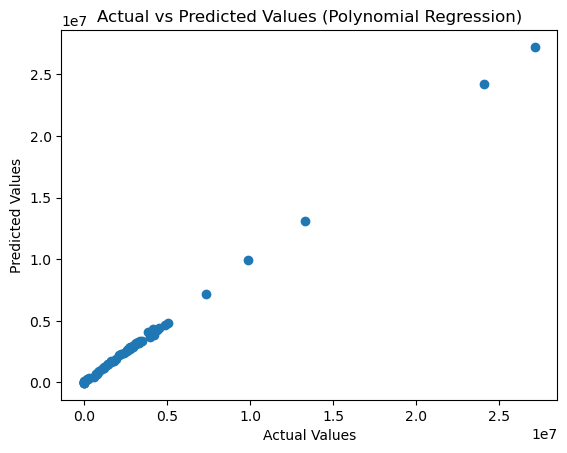

Polynomial Regression R-squared: 0.9995556591915336


In [16]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)
lin_reg2= LinearRegression()
lin_reg2.fit(X_poly, y)
X_test_poly = poly.transform(X_test)
plt.scatter(y_test, lin_reg2.predict(X_test_poly))
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')     
plt.title('Actual vs Predicted Values (Polynomial Regression)')
plt.show()
print("Polynomial Regression R-squared:", lin_reg2.score(X_test_poly, y_test))  
